In [4]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [5]:
digits = load_digits()

X = digits.data
y = digits.target

print("Dataset shape:", X.shape)
print("Target shape:", y.shape)

Dataset shape: (1797, 64)
Target shape: (1797,)


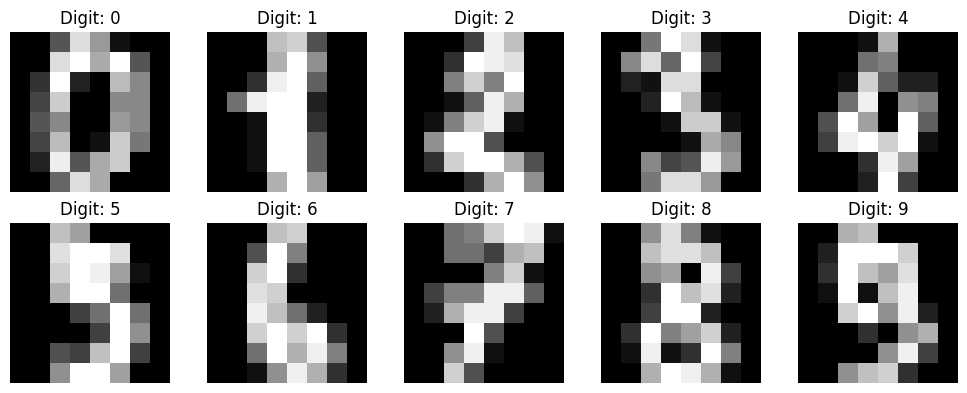

In [6]:
plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(digits.images[i], cmap='gray')
    plt.title("Digit: " + str(digits.target[i]))
    plt.axis('off')

plt.tight_layout()
plt.show()

In [7]:
print("Missing values:", np.isnan(X).sum())

Missing values: 0


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (1437, 64)
Testing data: (360, 64)


In [9]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Data standardization completed")

Data standardization completed


In [10]:
model = KNeighborsClassifier(n_neighbors=5)

print("KNN model created")

KNN model created


In [11]:
model.fit(X_train, y_train)

print("KNN model trained successfully")

KNN model trained successfully


In [12]:
y_pred = model.predict(X_test)

print("First 20 predictions:")
print(y_pred[:20])

First 20 predictions:
[6 9 3 7 2 1 5 2 5 2 1 9 4 0 4 2 3 7 8 8]


In [13]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy Percentage:", accuracy * 100, "%")

Accuracy: 0.975
Accuracy Percentage: 97.5 %


In [14]:
X_train_original, X_test_original, y_train_original, y_test_original = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

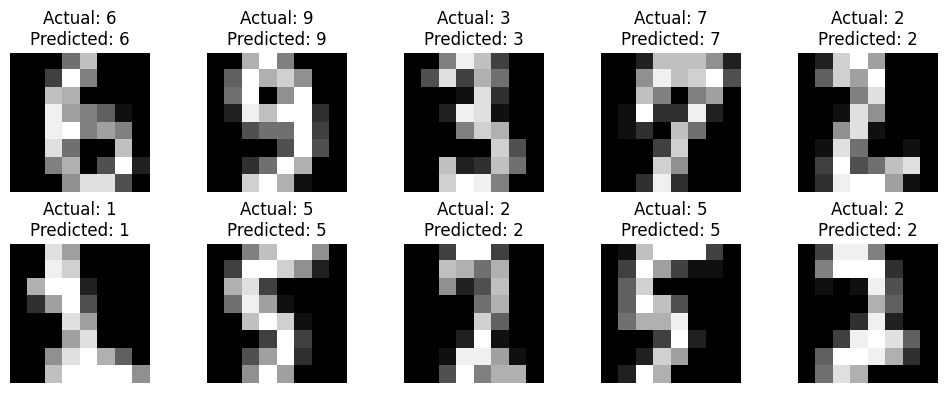

In [15]:
plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_test_original[i].reshape(8, 8), cmap='gray')
    plt.title(
        "Actual: " + str(y_test[i]) +
        "\nPredicted: " + str(y_pred[i])
    )
    plt.axis('off')

plt.tight_layout()
plt.show()

In [16]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[33  0  0  0  0  0  0  0  0  0]
 [ 0 28  0  0  0  0  0  0  0  0]
 [ 0  0 33  0  0  0  0  0  0  0]
 [ 0  0  1 33  0  0  0  0  0  0]
 [ 0  0  0  0 46  0  0  0  0  0]
 [ 0  0  0  0  0 45  1  0  0  1]
 [ 0  0  0  0  0  0 35  0  0  0]
 [ 0  0  0  0  0  1  0 32  0  1]
 [ 0  0  0  0  0  0  0  0 30  0]
 [ 0  0  0  1  1  1  0  0  1 36]]


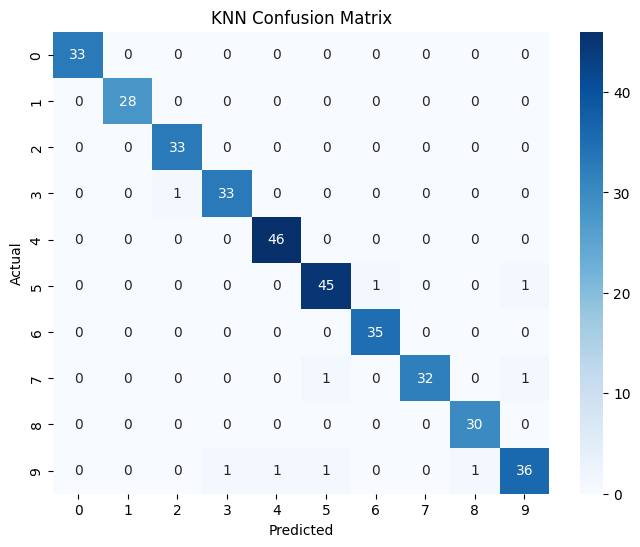

In [17]:
import seaborn as sns

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("KNN Confusion Matrix")

plt.show()

In [18]:
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        33
           1       1.00      1.00      1.00        28
           2       0.97      1.00      0.99        33
           3       0.97      0.97      0.97        34
           4       0.98      1.00      0.99        46
           5       0.96      0.96      0.96        47
           6       0.97      1.00      0.99        35
           7       1.00      0.94      0.97        34
           8       0.97      1.00      0.98        30
           9       0.95      0.90      0.92        40

    accuracy                           0.97       360
   macro avg       0.98      0.98      0.98       360
weighted avg       0.98      0.97      0.97       360



In [19]:
sample = X_test[0].reshape(1, -1)

prediction = model.predict(sample)

print("Actual Number:", y_test[0])
print("Predicted Number:", prediction[0])

Actual Number: 6
Predicted Number: 6


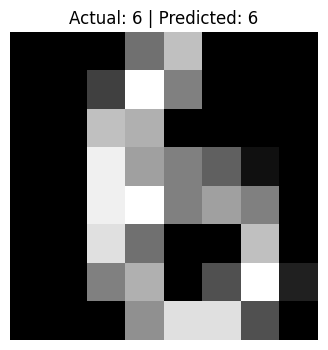

In [20]:
plt.figure(figsize=(4, 4))

plt.imshow(X_test_original[0].reshape(8, 8), cmap='gray')

plt.title(
    "Actual: " + str(y_test[0]) +
    " | Predicted: " + str(prediction[0])
)

plt.axis('off')
plt.show()

In [21]:
sample = X_test[10].reshape(1, -1)

prediction = model.predict(sample)

print("Actual Number:", y_test[10])
print("Predicted Number:", prediction[0])

Actual Number: 1
Predicted Number: 1


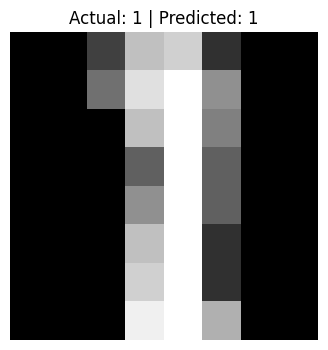

In [22]:
plt.figure(figsize=(4, 4))

plt.imshow(X_test_original[10].reshape(8, 8), cmap='gray')

plt.title(
    "Actual: " + str(y_test[10]) +
    " | Predicted: " + str(prediction[0])
)

plt.axis('off')
plt.show()